# 03 BMRA

Run BMRA based on global responses derived from the pathway activity predictions.

In [1]:
import pandas as pd
import numpy as np
import os
import bmra

In [2]:
cell_line = 'BC3C'

data_dir =f'/home/jing/Phd_project/project_UCD_blca/blca_publication_OUTPUT/blca_publication_OUTPUT_bmra/blca_publication_OUTPUT_bmra_{cell_line}_oct/'
data_dir_1 = os.path.join(data_dir, f'00_outputs_2020_{cell_line}/')
data_dir_2 = os.path.join(data_dir, f'01_outputs_2020_{cell_line}/')

info_dir =f"/home/jing/Phd_project/project_UCD_blca/blca_publication_OUTPUT/blca_publication_OUTPUT_LINCS/00_outputs_2020_{cell_line}/"

out_dir = os.path.join(data_dir,f'02_outputs_2020_{cell_line}/')


os.makedirs(out_dir, exist_ok = True)

## Load data

### Global responses

Assembled from global responses calculated from predicted pathway activities, and DPD global responses.

In [3]:
def assemble_R_global(pathway_rglobal_file, dpd_rglobal_file):
    """
    Assemble full R_global matrix
    """
    R_global_modules_df = pd.read_csv(pathway_rglobal_file, index_col = 0)

    perts = R_global_modules_df.columns.tolist()

    R_global_DPD_df = pd.read_csv(dpd_rglobal_file, index_col=0).T

    # filter by perts list
    R_global_DPD_df = R_global_DPD_df[R_global_DPD_df.index.isin(perts)]

    # sort by perts list
    R_global_DPD_df["sort_col"] = R_global_DPD_df.index.map({val: i for i, val in enumerate(perts)})
    R_global_DPD_df = R_global_DPD_df.sort_values("sort_col")
    R_global_DPD_df = R_global_DPD_df.drop("sort_col", axis = 1)

    # transpose
    R_global_DPD_df = R_global_DPD_df.T

    R_global_df = pd.concat([R_global_modules_df, R_global_DPD_df])

    return R_global_df

In [4]:
R_global_df = assemble_R_global(
    pathway_rglobal_file = os.path.join(data_dir_2, "R_global_annotated.csv"),
    dpd_rglobal_file = os.path.join(data_dir_1, "R_global_DPDonly_annotated.csv"),
)

modules = R_global_df.index.tolist()
exp_ids = R_global_df.columns.tolist()

R_global = R_global_df.values
n_modules = R_global.shape[0]

print(R_global.shape)
display(R_global_df)

(15, 106)


,ASG002_BC3C_24H:A10,ASG002_BC3C_24H:A11,ASG002_BC3C_24H:A19,ASG002_BC3C_24H:A20,ASG002_BC3C_24H:A21,ASG002_BC3C_24H:B10,ASG002_BC3C_24H:B11,ASG002_BC3C_24H:B14,ASG002_BC3C_24H:B15,ASG002_BC3C_24H:C13,...,MOAR011_BC3C_24H:C02,MOAR011_BC3C_24H:C03,MOAR011_BC3C_24H:C10,MOAR011_BC3C_24H:C11,MOAR011_BC3C_24H:F07,MOAR011_BC3C_24H:F08,MOAR011_BC3C_24H:F09,MOAR011_BC3C_24H:J10,TGFbRin,SMAD3in
Androgen,-0.052621,-0.009990,0.001874,-0.039472,0.001324,0.019733,0.004206,0.016562,0.020893,0.035649,...,-0.001679,-0.009316,-0.053252,-0.005367,-0.055305,0.028579,0.026119,-0.585968,-0.009139,0.006162
CDK1_2,-0.621082,-0.531031,0.093002,-0.056078,0.080421,-0.266776,0.049598,-0.323796,0.120332,0.070655,...,-0.140913,0.049986,-0.114174,0.012147,-0.807172,0.122808,-0.042203,0.057063,-0.041460,-0.484842
CDK4_6,-0.024936,-0.233707,-0.041751,-0.514436,0.040579,0.002081,-0.008150,0.097358,0.086051,0.031921,...,0.097750,-0.089140,-1.036780,-1.207947,0.318628,0.199218,-0.063101,-0.014375,0.243961,-0.735755
EGFR,0.595317,0.495997,0.227641,0.366392,0.491113,0.114004,-0.413685,0.264438,0.284352,-0.045713,...,-0.056304,-0.035652,-0.086204,-0.423370,-0.437931,-0.554481,-0.316714,-0.228032,-0.240228,-0.852414
Estrogen,-0.123581,-0.206520,-0.210390,-0.408850,-0.948934,-0.310324,-0.086625,-0.236793,-0.163154,-0.040838,...,0.039947,-0.011210,0.023137,0.134809,-1.511066,-0.227770,0.183108,-0.253387,0.095644,-0.273029
FGFR,-0.110826,-0.176615,-0.089973,0.051372,-0.028303,-0.407054,-0.033356,-0.026203,-0.061578,-0.300794,...,0.048645,-0.023038,0.027171,-0.236077,-0.548053,0.023803,0.222081,0.037442,-0.276134,-0.698995
PI3K,-1.905384,-1.706779,-1.427511,-1.235968,-0.703423,0.292413,-0.145389,-0.189694,-0.848614,-0.279918,...,-0.047315,-0.516501,-0.513706,0.010704,-0.832753,0.221675,-0.238456,0.010389,-0.018707,-0.094551
p53,-0.208180,-0.220330,-0.126568,-0.402443,0.054129,-1.629256,-1.474548,-0.119131,-0.085082,-1.327909,...,0.027714,0.239815,0.203075,0.280463,-0.227430,-0.049061,0.029911,0.600581,0.065568,0.164890
TOP2A,-0.225857,0.074982,-0.234867,-0.172053,-0.126895,0.054219,0.071537,-1.999303,-0.205636,-0.288424,...,0.077445,-0.176942,-0.523301,0.050593,-0.750866,-0.009134,-0.032931,-0.440533,0.246082,0.134996
Src,-0.930922,-1.681221,0.523029,-1.207023,0.571560,-1.128624,0.495749,0.394395,0.396866,0.447353,...,0.060890,0.062826,-0.104232,-0.013038,0.039772,0.245412,0.777845,-0.155845,-0.153134,-0.069255


In [5]:
print(R_global_df.values.min())
print(R_global_df.values.max())

-141.3271606788109
23.679038382410333


### Perturbation matrix

In [6]:
inhib_conc_df = pd.read_csv(os.path.join(data_dir_1, "inhib_conc_annotated.csv"), index_col = 0)
#LFC_PLCg = pd.read_csv(os.path.join(info_dir,"PLCg_Data_log_2020.csv"),index_col=0)
#inhib_conc = inhib_conc_df.drop(columns=LFC_PLCg.index).values
inhib_conc = inhib_conc_df.values

n_DPDs = R_global.shape[0] - inhib_conc.shape[0]

pert_modules = np.where(inhib_conc != 0, 1, 0)
pert_DPD = np.zeros((n_DPDs, len(exp_ids)))

pert = np.vstack([pert_modules, pert_DPD])

print(pert.shape)
print(pert)

(15, 106)
[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


### Networks

In [7]:
# empty prior
#G_prior = np.zeros((n_modules, n_modules))
G_prior_df = pd.read_excel(os.path.join(info_dir, "ALL_DATA_2020_oct25.xlsx"), sheet_name = "prior_net_work", index_col = 0)

G_prior = G_prior_df.values
G_prior_df

,CDK1_2,CDK4_6,EGFR,PI3K,FGFR,TOP2A,p53,Src,TGFb,Estrogen,Androgen,SMAD3,blca_inv,blca_onc,surv_coef
CDK1_2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
CDK4_6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
EGFR,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
PI3K,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
FGFR,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
TOP2A,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
p53,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Src,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
TGFb,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Estrogen,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [46]:
#G_prior_r_df = pd.read_excel(os.path.join(info_dir, "ALL_DATA_2020.xlsx"), sheet_name = "prior_r", index_col = 0)

#G_prior_r = G_prior_r_df.values
#G_prior_r_df

In [8]:
G_not = np.eye(n_modules)
G_not[:, n_modules - n_DPDs :] = 1

G_not

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0.

## Run BMRA

In [9]:
n_gibbs = 200_000
n_window = 5_000

mode = "all"
n_iterations = 1

In [10]:
A_mean, A_sd, r_mean, r_sd = bmra.run_bmra(R_global,
            pert,
            G_prior,
            G_not,
            #r_prior = G_prior_r,
            n_gibbs = n_gibbs,
            n_window = n_window,
            mode = mode,
            n_iterations = n_iterations,
        )

A_mean_df = pd.DataFrame(A_mean, index = modules, columns = modules)
A_sd_df = pd.DataFrame(A_sd, index = modules, columns = modules)
r_mean_df = pd.DataFrame(r_mean, index = modules, columns = modules)
r_sd_df = pd.DataFrame(r_sd, index = modules, columns = modules)

display(A_mean_df)
display(A_sd_df)
display(r_mean_df)
display(r_sd_df)

A_mean_df.to_csv(os.path.join(out_dir, "A_mean.csv"))
A_sd_df.to_csv(os.path.join(out_dir, "A_sd.csv"))
r_mean_df.to_csv(os.path.join(out_dir, "r_mean.csv"))
r_sd_df.to_csv(os.path.join(out_dir, "r_sd.csv"))

,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.001345,0.000669,0.00000,0.001988,0.0,0.0,0.0,0.0,0.0
CDK1_2,0.0,0.000000,0.003824,0.965752,0.000000,0.831405,1.000000,0.000000,0.00000,0.270786,0.0,0.0,0.0,0.0,0.0
CDK4_6,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.00000,0.220232,0.0,0.0,0.0,0.0,0.0
EGFR,0.0,0.000000,1.000000,0.000000,0.000000,0.928733,1.000000,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0
Estrogen,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.00000,0.395523,0.0,0.0,0.0,0.0,0.0
FGFR,0.0,0.000000,0.036216,1.000000,0.064252,0.000000,0.971446,0.841277,0.00000,0.009266,0.0,0.0,0.0,0.0,0.0
PI3K,0.0,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.0,0.0,0.0,0.0,0.0
p53,0.0,0.001492,0.000625,1.000000,0.000849,0.000596,0.872896,0.000000,0.02690,0.001736,0.0,0.0,0.0,0.0,0.0
TOP2A,0.0,0.000000,0.000000,1.000000,0.012219,0.000000,1.000000,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0
Src,0.0,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.0,0.000000e+00,0.000000e+00,2.220446e-16,0.000000e+00,0.000000e+00,3.664376e-02,2.584905e-02,0.000000e+00,0.044539,0.0,0.0,0.0,0.0,0.0
CDK1_2,0.0,0.000000e+00,6.171937e-02,1.818649e-01,0.000000e+00,3.743941e-01,6.661338e-16,0.000000e+00,0.000000e+00,0.444366,0.0,0.0,0.0,0.0,0.0
CDK4_6,0.0,0.000000e+00,0.000000e+00,3.774758e-15,0.000000e+00,0.000000e+00,3.774758e-15,0.000000e+00,0.000000e+00,0.414403,0.0,0.0,0.0,0.0,0.0
EGFR,0.0,0.000000e+00,1.110223e-15,0.000000e+00,0.000000e+00,2.572695e-01,1.110223e-15,0.000000e+00,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0
Estrogen,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.330669e-16,3.330669e-16,0.000000e+00,0.000000e+00,0.488963,0.0,0.0,0.0,0.0,0.0
FGFR,0.0,0.000000e+00,1.868273e-01,2.664535e-15,2.452008e-01,0.000000e+00,1.665507e-01,3.654172e-01,0.000000e+00,0.095812,0.0,0.0,0.0,0.0,0.0
PI3K,0.0,1.110223e-15,0.000000e+00,1.110223e-15,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.110223e-15,0.000000,0.0,0.0,0.0,0.0,0.0
p53,0.0,3.859607e-02,2.499043e-02,1.332268e-15,2.912172e-02,2.441606e-02,3.330891e-01,0.000000e+00,1.617899e-01,0.041625,0.0,0.0,0.0,0.0,0.0
TOP2A,0.0,0.000000e+00,0.000000e+00,6.661338e-16,1.098628e-01,0.000000e+00,6.661338e-16,0.000000e+00,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0
Src,0.0,0.000000e+00,0.000000e+00,1.443290e-15,1.443290e-15,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.0,0.000000,0.000000,-0.045688,0.000000,0.000000,0.000015,0.000001,0.000000,0.000010,0.0,0.0,0.0,0.0,0.0
CDK1_2,0.0,0.000000,0.000512,0.152926,0.000000,0.151669,0.236897,0.000000,0.000000,0.022102,0.0,0.0,0.0,0.0,0.0
CDK4_6,0.0,0.000000,0.000000,0.381471,0.000000,0.000000,0.150728,0.000000,0.000000,0.019087,0.0,0.0,0.0,0.0,0.0
EGFR,0.0,0.000000,0.212630,0.000000,0.000000,0.201496,-0.300807,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Estrogen,0.0,0.000000,0.000000,0.000000,0.000000,0.272102,0.139507,0.000000,0.000000,0.034975,0.0,0.0,0.0,0.0,0.0
FGFR,0.0,0.000000,0.005312,0.376973,0.012386,0.000000,0.133583,0.106717,0.000000,0.000491,0.0,0.0,0.0,0.0,0.0
PI3K,0.0,0.402999,0.000000,-0.204695,0.000000,0.000000,0.000000,0.000000,0.571983,0.000000,0.0,0.0,0.0,0.0,0.0
p53,0.0,0.000163,0.000001,0.222380,0.000095,0.000045,0.152059,0.000000,0.006531,0.000027,0.0,0.0,0.0,0.0,0.0
TOP2A,0.0,0.000000,0.000000,-0.133790,0.001617,0.000000,0.167740,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Src,0.0,0.000000,0.000000,0.261301,0.536224,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.0,0.000000,0.000000,0.012862,0.000000,0.000000,0.000511,0.000122,0.000000,0.000402,0.0,0.0,0.0,0.0,0.0
CDK1_2,0.0,0.000000,0.008378,0.045342,0.000000,0.076998,0.027918,0.000000,0.000000,0.037682,0.0,0.0,0.0,0.0,0.0
CDK4_6,0.0,0.000000,0.000000,0.021831,0.000000,0.000000,0.015080,0.000000,0.000000,0.037269,0.0,0.0,0.0,0.0,0.0
EGFR,0.0,0.000000,0.050733,0.000000,0.000000,0.075375,0.024108,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Estrogen,0.0,0.000000,0.000000,0.000000,0.000000,0.032093,0.015227,0.000000,0.000000,0.045795,0.0,0.0,0.0,0.0,0.0
FGFR,0.0,0.000000,0.028608,0.039766,0.048689,0.000000,0.036574,0.055585,0.000000,0.005443,0.0,0.0,0.0,0.0,0.0
PI3K,0.0,0.032394,0.000000,0.026558,0.000000,0.000000,0.000000,0.000000,0.037234,0.000000,0.0,0.0,0.0,0.0,0.0
p53,0.0,0.004904,0.001243,0.056344,0.003794,0.002236,0.071269,0.000000,0.041102,0.001799,0.0,0.0,0.0,0.0,0.0
TOP2A,0.0,0.000000,0.000000,0.021275,0.014760,0.000000,0.020196,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Src,0.0,0.000000,0.000000,0.044411,0.064775,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [11]:
np.fill_diagonal(r_mean_df.values,-1)
rm_minus_inv = pd.DataFrame(np.linalg.pinv(r_mean_df),index=r_mean_df.index,columns=r_mean_df.columns)*(-1)
rm_minus_inv.to_csv(os.path.join(out_dir, 'r_minv.csv'))
display(rm_minus_inv)

,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,1.000000e+00,7.041213e-03,-1.252426e-02,-5.864893e-02,-1.631331e-04,-1.079403e-02,1.747250e-02,-1.150431e-03,9.986462e-03,-8.480862e-05,1.434138e-18,1.095739e-17,-5.726083e-17,1.125381e-16,-1.419992e-17
CDK1_2,3.223661e-16,1.108066e+00,4.499695e-02,2.036160e-01,1.686323e-02,2.136771e-01,2.681461e-01,2.280289e-02,1.535240e-01,2.604516e-02,8.558132e-17,2.040490e-15,1.699087e-17,-5.300458e-16,2.207622e-16
CDK4_6,9.724023e-17,2.302328e-02,1.096344e+00,4.506055e-01,1.302990e-02,9.783306e-02,5.712565e-02,1.044041e-02,3.274309e-02,2.193885e-02,3.385696e-17,6.183792e-16,4.997990e-17,1.202103e-16,3.193942e-16
EGFR,1.110658e-17,-1.539372e-01,2.741217e-01,1.283663e+00,3.689308e-03,2.363103e-01,-3.819893e-01,2.521823e-02,-2.183267e-01,2.075606e-03,-1.722351e-17,-2.388433e-16,5.905704e-17,4.686153e-16,2.985367e-17
Estrogen,7.643623e-17,8.135955e-02,2.273218e-02,9.894300e-02,1.024537e+00,3.110568e-01,2.018719e-01,3.319491e-02,1.156841e-01,3.821931e-02,7.596968e-17,1.048699e-15,-3.468380e-17,-6.087124e-17,-1.361531e-16
FGFR,1.268806e-16,2.072952e-02,1.061911e-01,4.718257e-01,1.563362e-02,1.102474e+00,5.139069e-02,1.176523e-01,3.016295e-02,3.576707e-03,1.180233e-16,2.069209e-15,6.167774e-17,6.069613e-16,1.862959e-16
PI3K,-3.339610e-16,5.419083e-01,-6.518827e-02,-3.084361e-01,7.417898e-03,2.206081e-02,1.344688e+00,2.354254e-03,7.691542e-01,1.100356e-02,1.784459e-16,3.525105e-15,-1.398900e-17,-6.842155e-16,-6.693696e-16
p53,-1.351051e-16,4.908716e-02,5.075383e-02,2.371774e-01,2.080352e-03,5.584669e-02,1.213989e-01,1.005960e+00,7.600770e-02,2.181329e-03,-1.567814e-17,4.297830e-16,-3.166045e-17,6.473321e-16,-1.658570e-16
TOP2A,7.828050e-17,1.116267e-01,-4.757270e-02,-2.233185e-01,2.407790e-03,-2.741239e-02,2.769911e-01,-2.925356e-03,1.158415e+00,1.629860e-03,8.865207e-17,1.947972e-15,1.598681e-17,-2.462085e-16,-1.142317e-16
Src,-6.529374e-18,3.402967e-03,8.381795e-02,3.884786e-01,5.503459e-01,2.285444e-01,8.434271e-03,2.438948e-02,4.983540e-03,1.021036e+00,2.479098e-17,3.171437e-16,-8.147662e-17,-9.052166e-17,4.021216e-17


In [12]:
con_mat = pd.DataFrame(columns=['From','To','Strength'])
for con_to in r_mean_df.index:
    for con_from in r_mean_df.columns:
        if ((r_mean_df.loc[con_to,con_from] != 0) & (con_from != con_to)):
            row_df = pd.DataFrame([[con_from,con_to,r_mean_df.loc[con_to,con_from]]],columns=['From','To','Strength'])
            if con_mat.empty:
                con_mat = row_df.copy()
            else:
                con_mat = pd.concat([con_mat,row_df],axis=0,ignore_index=True)
            #con_mat = con_mat.append({'From':con_from,'To':con_to,'Strength':r_mean_df.loc[con_to,con_from]},ignore_index=True)
con_mat.to_csv(os.path.join(out_dir, 'r_net.txt'),sep='\t',index=False)
display(con_mat)

,From,To,Strength
0,EGFR,Androgen,-0.045688
1,PI3K,Androgen,0.000015
2,p53,Androgen,0.000001
3,Src,Androgen,0.000010
4,CDK4_6,CDK1_2,0.000512
5,EGFR,CDK1_2,0.152926
6,FGFR,CDK1_2,0.151669
7,PI3K,CDK1_2,0.236897
8,Src,CDK1_2,0.022102
9,EGFR,CDK4_6,0.381471


In [13]:
# now the same but with filtered matrices
# threshold value
Athr = 0.5

rm_filt = r_mean_df[np.abs(A_mean_df) > Athr].fillna(0).copy()
np.fill_diagonal(rm_filt.values,-1)
rm_filt.to_csv(os.path.join(out_dir, 'r_mean_filt.csv'))
display(rm_filt)

rm_filt_minus_inv = pd.DataFrame(np.linalg.pinv(rm_filt),index=rm_filt.index,columns=rm_filt.columns)*(-1)
rm_filt_minus_inv.to_csv(os.path.join(out_dir, 'r_minv_filt.csv'))
display(rm_minus_inv)

con_mat = pd.DataFrame(columns=['From','To','Strength'])
for con_to in rm_filt.index:
    for con_from in rm_filt.columns:
        if ((rm_filt.loc[con_to,con_from] != 0) & (con_from != con_to)):
            row_df = pd.DataFrame([[con_from,con_to,rm_filt.loc[con_to,con_from]]],columns=['From','To','Strength'])
            if con_mat.empty:
                con_mat = row_df.copy()
            else:
                con_mat = pd.concat([con_mat,row_df],axis=0,ignore_index=True)
            #con_mat = con_mat.append({'From':con_from,'To':con_to,'Strength':r_mean_df.loc[con_to,con_from]},ignore_index=True)
con_mat.to_csv(os.path.join(out_dir, 'r_net_filt.txt'),sep='\t',index=False)
#display(con_mat)


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,-1.0,0.000000,0.00000,-0.045688,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
CDK1_2,0.0,-1.000000,0.00000,0.152926,0.000000,0.151669,0.236897,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
CDK4_6,0.0,0.000000,-1.00000,0.381471,0.000000,0.000000,0.150728,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
EGFR,0.0,0.000000,0.21263,-1.000000,0.000000,0.201496,-0.300807,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
Estrogen,0.0,0.000000,0.00000,0.000000,-1.000000,0.272102,0.139507,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
FGFR,0.0,0.000000,0.00000,0.376973,0.000000,-1.000000,0.133583,0.106717,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
PI3K,0.0,0.402999,0.00000,-0.204695,0.000000,0.000000,-1.000000,0.000000,0.571983,0.0,0.0,0.0,0.0,0.0,0.0
p53,0.0,0.000000,0.00000,0.222380,0.000000,0.000000,0.152059,-1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
TOP2A,0.0,0.000000,0.00000,-0.133790,0.000000,0.000000,0.167740,0.000000,-1.000000,0.0,0.0,0.0,0.0,0.0,0.0
Src,0.0,0.000000,0.00000,0.261301,0.536224,0.000000,0.000000,0.000000,0.000000,-1.0,0.0,0.0,0.0,0.0,0.0


,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,1.000000e+00,7.041213e-03,-1.252426e-02,-5.864893e-02,-1.631331e-04,-1.079403e-02,1.747250e-02,-1.150431e-03,9.986462e-03,-8.480862e-05,1.434138e-18,1.095739e-17,-5.726083e-17,1.125381e-16,-1.419992e-17
CDK1_2,3.223661e-16,1.108066e+00,4.499695e-02,2.036160e-01,1.686323e-02,2.136771e-01,2.681461e-01,2.280289e-02,1.535240e-01,2.604516e-02,8.558132e-17,2.040490e-15,1.699087e-17,-5.300458e-16,2.207622e-16
CDK4_6,9.724023e-17,2.302328e-02,1.096344e+00,4.506055e-01,1.302990e-02,9.783306e-02,5.712565e-02,1.044041e-02,3.274309e-02,2.193885e-02,3.385696e-17,6.183792e-16,4.997990e-17,1.202103e-16,3.193942e-16
EGFR,1.110658e-17,-1.539372e-01,2.741217e-01,1.283663e+00,3.689308e-03,2.363103e-01,-3.819893e-01,2.521823e-02,-2.183267e-01,2.075606e-03,-1.722351e-17,-2.388433e-16,5.905704e-17,4.686153e-16,2.985367e-17
Estrogen,7.643623e-17,8.135955e-02,2.273218e-02,9.894300e-02,1.024537e+00,3.110568e-01,2.018719e-01,3.319491e-02,1.156841e-01,3.821931e-02,7.596968e-17,1.048699e-15,-3.468380e-17,-6.087124e-17,-1.361531e-16
FGFR,1.268806e-16,2.072952e-02,1.061911e-01,4.718257e-01,1.563362e-02,1.102474e+00,5.139069e-02,1.176523e-01,3.016295e-02,3.576707e-03,1.180233e-16,2.069209e-15,6.167774e-17,6.069613e-16,1.862959e-16
PI3K,-3.339610e-16,5.419083e-01,-6.518827e-02,-3.084361e-01,7.417898e-03,2.206081e-02,1.344688e+00,2.354254e-03,7.691542e-01,1.100356e-02,1.784459e-16,3.525105e-15,-1.398900e-17,-6.842155e-16,-6.693696e-16
p53,-1.351051e-16,4.908716e-02,5.075383e-02,2.371774e-01,2.080352e-03,5.584669e-02,1.213989e-01,1.005960e+00,7.600770e-02,2.181329e-03,-1.567814e-17,4.297830e-16,-3.166045e-17,6.473321e-16,-1.658570e-16
TOP2A,7.828050e-17,1.116267e-01,-4.757270e-02,-2.233185e-01,2.407790e-03,-2.741239e-02,2.769911e-01,-2.925356e-03,1.158415e+00,1.629860e-03,8.865207e-17,1.947972e-15,1.598681e-17,-2.462085e-16,-1.142317e-16
Src,-6.529374e-18,3.402967e-03,8.381795e-02,3.884786e-01,5.503459e-01,2.285444e-01,8.434271e-03,2.438948e-02,4.983540e-03,1.021036e+00,2.479098e-17,3.171437e-16,-8.147662e-17,-9.052166e-17,4.021216e-17


In [14]:
# number of zero elements in the matrix
display(len(rm_filt.index)*len(rm_filt.columns) - rm_filt.astype(bool).sum().sum())

178

In [15]:
# number of non-zero elements in the matrix
display(rm_filt.astype(bool).sum().sum() - len(modules))

32

### Visualization

In [16]:
df_subset=rm_filt_minus_inv[['Androgen', 'CDK1_2', 'CDK4_6', 'EGFR', 'Estrogen', 'FGFR',
       'p53','PI3K',  'TOP2A','Src','TGFb','SMAD3']]
df_subset = df_subset.loc[['blca_basal_luminal',	'blca_oncogenesis',	'blca_survival']]

In [17]:
t_df_subset=df_subset.T
df_subset.reset_index(inplace=True)

Text(0.5, 1.0, 'Predicted global signaling pathway responses of BC3C cell line (LFC integrated)')

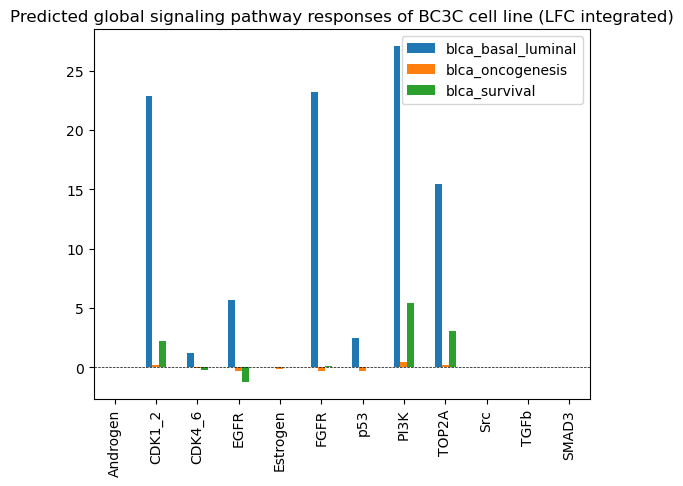

In [22]:
import matplotlib.pyplot as plt
t_df_subset.plot.bar()
plt.axhline(y=0, linestyle='--', color='black',linewidth=0.5)
plt.title(f"Predicted global signaling pathway responses of {cell_line} cell line (LFC integrated)")

In [19]:
display(rm_filt)
rm_subset=rm_filt[['Androgen','CDK1_2', 'CDK4_6', 'EGFR', 'Estrogen', 'FGFR',
       'PI3K', 'p53', 'TOP2A','Src','TGFb']]

,Androgen,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,TGFb,SMAD3,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,-1.0,0.000000,0.00000,-0.045688,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
CDK1_2,0.0,-1.000000,0.00000,0.152926,0.000000,0.151669,0.236897,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
CDK4_6,0.0,0.000000,-1.00000,0.381471,0.000000,0.000000,0.150728,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
EGFR,0.0,0.000000,0.21263,-1.000000,0.000000,0.201496,-0.300807,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
Estrogen,0.0,0.000000,0.00000,0.000000,-1.000000,0.272102,0.139507,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
FGFR,0.0,0.000000,0.00000,0.376973,0.000000,-1.000000,0.133583,0.106717,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
PI3K,0.0,0.402999,0.00000,-0.204695,0.000000,0.000000,-1.000000,0.000000,0.571983,0.0,0.0,0.0,0.0,0.0,0.0
p53,0.0,0.000000,0.00000,0.222380,0.000000,0.000000,0.152059,-1.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
TOP2A,0.0,0.000000,0.00000,-0.133790,0.000000,0.000000,0.167740,0.000000,-1.000000,0.0,0.0,0.0,0.0,0.0,0.0
Src,0.0,0.000000,0.00000,0.261301,0.536224,0.000000,0.000000,0.000000,0.000000,-1.0,0.0,0.0,0.0,0.0,0.0


In [20]:
rm_subset=rm_subset.loc[['blca_basal_luminal',	'blca_oncogenesis',	'blca_survival']]
rm_subset=rm_subset.T
display(rm_subset)

,blca_basal_luminal,blca_oncogenesis,blca_survival
Androgen,0.000000,0.000000,0.000000
CDK1_2,11.944237,0.000000,0.000000
CDK4_6,0.000000,0.000000,0.000000
EGFR,0.000000,0.000000,0.000000
Estrogen,0.000000,-0.179850,0.000000
FGFR,18.628185,-0.259066,0.000000
PI3K,17.093560,0.360606,4.029178
p53,0.000000,-0.237762,0.000000
TOP2A,0.000000,0.000000,0.000000
Src,0.000000,0.000000,0.000000


Text(0.5, 1.0, 'Predicted local signaling pathway responses of BC3C cell line (LFC integrated)')

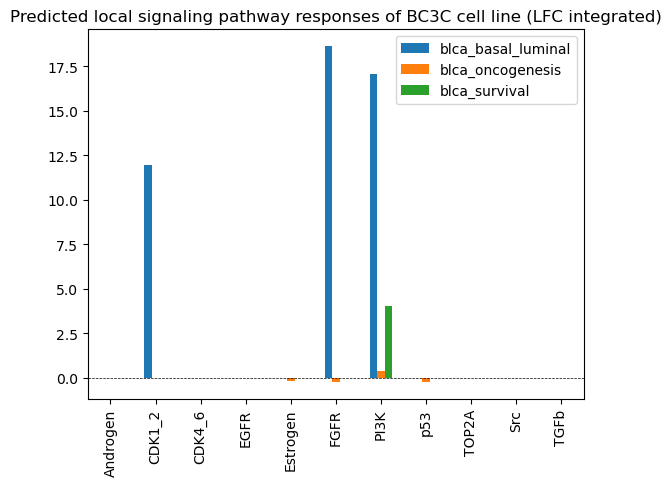

In [23]:
rm_subset.plot.bar()
plt.axhline(y=0, linestyle='--', color='black',linewidth=0.5)
plt.title(f"Predicted local signaling pathway responses of {cell_line} cell line (LFC integrated)")